In [ ]:
!pip install augly aum

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import random

# Step 1: Load CIFAR-10 dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

# Step 2: Introduce Label Noise in TEST SET ONLY
np.random.seed(42)
noise_ratio = 0.2
num_test_samples = len(test_dataset.targets)
true_noisy_indices = random.sample(range(num_test_samples), int(noise_ratio * num_test_samples))
ground_truth_labels = np.array(test_dataset.targets).copy() # Store true labels
noisy_test_labels = ground_truth_labels.copy()

for idx in true_noisy_indices:
    while(noisy_test_labels[idx] == ground_truth_labels[idx]):
        #print(idx, noisy_test_labels[idx], ground_truth_labels[idx])
        noisy_test_labels[idx] = random.randint(0, 9)

test_dataset.targets = noisy_test_labels

# Step 3: Define a Simple CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Step 4: Train Model on CLEAN TRAIN DATA
batch_size = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = SimpleCNN().to(device)
model.load_state_dict(torch.load('label_noise_simplecnn.h5', weights_only=True))

<All keys matched successfully>

In [16]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    predicted_labels, true_labels = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
            predicted_labels.extend(predicted.cpu().numpy())
            true_labels.extend(targets.cpu().numpy())
    return 100 * correct / total, np.array(predicted_labels), np.array(true_labels)

def wrong_prediction_indice_method(model, test_loader):
    test_accuracy, predicted_labels, truth_labels = evaluate(model, test_loader)
    mismatched_indices = np.where(predicted_labels != truth_labels)[0]
    return mismatched_indices

In [14]:
def evaluate_noisy_indices(detected_indices, true_indices):

    detected_noisy_set = set(detected_indices)
    true_noisy = set(true_indices)

    correct_detections = len(detected_noisy_set.intersection(true_noisy))
    precision = correct_detections / len(detected_noisy_set) if len(detected_noisy_set) > 0 else 0
    recall = correct_detections / len(true_noisy) if len(true_noisy) > 0 else 0
    accuracy = correct_detections / len(true_noisy.union(detected_noisy_set))


    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}") #proselflc

    return precision, recall, accuracy

In [17]:
indices0 = wrong_prediction_indice_method(model, test_loader)
evaluate_noisy_indices(indices0, true_noisy_indices)

Precision: 0.4660, Recall: 0.9685, Accuracy: 0.4590


(0.46596102958864566, 0.9685, 0.4590047393364929)

In [19]:
import torch
import torch.nn.functional as F
import numpy as np

def track_loss_per_sample_multiple_epochs(model, train_loader, num_epochs, device):
    loss_per_sample_over_epochs = {i: [] for i in range(len(train_loader.dataset))}  # ✅ Initialize dictionary with all indices

    model.train()  # Ensure model is in training mode

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        batch_start_idx = 0  # ✅ Track sample index across batches

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Compute per-sample loss
            per_sample_loss = F.cross_entropy(outputs, labels, reduction='none')  # ✅ Fix

            # Store loss for each sample
            for i in range(len(inputs)):
                global_idx = batch_start_idx + i  # ✅ Compute global index correctly
                loss_per_sample_over_epochs[global_idx].append(per_sample_loss[i].item())

            batch_start_idx += len(inputs)  # ✅ Move index forward

    return loss_per_sample_over_epochs

def loss_indice_method(model, test_loader, threshold=20):
    # Example: track loss for 10 epochs
    loss_per_sample_over_epochs = track_loss_per_sample_multiple_epochs(model, 
                                                                        test_loader, 
                                                                        num_epochs=10, 
                                                                        device=device
                                                                       )

    # Aggregate losses per sample
    sample_losses = [(idx, np.mean(losses)) for idx, losses in loss_per_sample_over_epochs.items()]
    sample_losses.sort(key=lambda x: x[1], reverse=True)  # Sort by highest loss
    num_noisy = int(len(sample_losses) *(threshold/100))
    lossy_noisy_indices = [idx for idx, loss in sample_losses[:num_noisy]]
    return lossy_noisy_indices

In [20]:
indices1 = loss_indice_method(model, test_loader)
evaluate_noisy_indices(indices1, true_noisy_indices)

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
Precision: 0.8060, Recall: 0.8060, Accuracy: 0.6750


(0.806, 0.806, 0.6750418760469011)

In [5]:
from aum import AUMCalculator, DatasetWithIndex
import pandas as pd

def aum_indice_method(model, test_loader):
    save_dir = '~/Desktop'
    aum_calculator = AUMCalculator(save_dir, compressed=True)
    test_dataset = test_loader.dataset
    test_dataset_idx = DatasetWithIndex(test_dataset)
    test_loader_idx = torch.utils.data.DataLoader(test_dataset_idx, batch_size=batch_size, shuffle=False)

    model.eval()
    for batch in test_loader_idx:

        inputs, targets, sample_ids = batch
        logits = model(inputs)
        records = aum_calculator.update(logits, targets, sample_ids)

    aum_calculator.finalize()
    aum_values = pd.read_csv('aum_values.csv')
    aum_idx = [int(x.replace('tensor(', '').replace(')', '')) for x in aum_values[-2000:]['sample_id']]
    return aum_idx

In [21]:
indices2 = aum_indice_method(model, test_loader)
evaluate_noisy_indices(indices2, true_noisy_indices)

Precision: 0.8040, Recall: 0.8040, Accuracy: 0.6722


(0.804, 0.804, 0.6722408026755853)

In [6]:
from FINE_official.dynamic_selection.selection.svd_classifier import get_score, get_singular_vector, get_mean_vector
import numpy as np
from tqdm import tqdm

def get_logits(model, dataloader):
    '''
    Concatenate the hidden features and corresponding labels 
    on CPU
    '''
    labels = np.empty((0,))

    model.eval()  # Ensure the model is in evaluation mode
    with tqdm(dataloader) as progress:
#         print(next(iter(progress)))
        for batch_idx, (data, label) in enumerate(progress):
            data, label = data, label.long()  # No need to move to GPU, stay on CPU
            feature = model(data)  # Forward pass

            labels = np.concatenate((labels, label.cpu()))  # Ensure labels are on CPU
            if batch_idx == 0:
                features = feature.detach().cpu()  # Ensure features are on CPU
            else:
                features = np.concatenate((features, feature.detach().cpu()), axis=0)
    
    return features, labels


def fine_indice_method(model, test_loader, norm=True, eigen=True, thres=20):

    features, labels = get_logits(model, test_loader)  # Extract feature representations

    # Eigen decomposition or mean-based features
    if eigen:
        vector_dict = get_singular_vector(features, labels)
    else:
        vector_dict = get_mean_vector(features, labels)

    # Calculate alignment scores
    scores = get_score(vector_dict, features=features, labels=labels, normalization=norm)

    # Dynamically set threshold based on percentile
    threshold = np.percentile(scores, thres)  # Taking 95th percentile as threshold
    print(f"Threshold for clean labels: {threshold}")

    # Mark labels above threshold as clean
    clean_labels = np.where(scores > threshold)[0]
    noisy_labels = np.setdiff1d(np.arange(len(scores)), clean_labels)
    return noisy_labels



In [22]:
indices3 = fine_indice_method(model, test_loader)
evaluate_noisy_indices(indices3, true_noisy_indices)

100%|███████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 113446.03it/s]

Threshold for clean labels: 0.5960746765136719
Precision: 0.6890, Recall: 0.6890, Accuracy: 0.5256


(0.689, 0.689, 0.5255530129672006)

In [24]:
import torch
import numpy as np

class LabelUpdate:
    def __init__(self, dataloader, model, device, args):
        self.dataloader = dataloader  # DataLoader for test or training set
        self.model = model.to(device)  # Move model to GPU if available
        self.device = device
        self.args = args

        self.count = 0  # Track epoch count
        self.num_samples = len(dataloader.dataset)
        self.num_classes = 10

        # Store past 10 epoch predictions
        self.prediction = np.zeros((self.num_samples, 10, self.num_classes))  

        # Soft label estimates & noisy label tracking
        self.soft_labels = np.zeros((self.num_samples, self.num_classes))
        self.noisy_indices = set()  # Track detected noisy labels

    @torch.no_grad()
    def label_update(self):
        self.count += 1
        self.model.eval()  # Set model to evaluation mode

        all_preds = []
        all_targets = []
        all_indices = []

        # Run inference on dataset
        for batch_idx, (inputs, targets) in enumerate(self.dataloader):
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            outputs = self.model(inputs)  # Get predictions
            probs = torch.nn.functional.softmax(outputs, dim=1)  # Convert logits to probabilities
            
            all_preds.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_indices.append(np.arange(batch_idx * 128, 
                                         batch_idx * 128 + len(targets)))

        # Stack predictions & labels
        all_preds = np.vstack(all_preds)
        all_targets = np.hstack(all_targets)
        all_indices = np.hstack(all_indices)

        # Store latest predictions (sliding window of 10 epochs)
        idx = (self.count - 1) % 10
        self.prediction[all_indices, idx] = all_preds  

        # Start detecting noisy labels after a few epochs
        if self.count >= 70:
            self.soft_labels = self.prediction.mean(axis=1)  # Average soft labels
            predicted_labels = np.argmax(self.soft_labels, axis=1)

            # Detect noisy labels (where soft label disagrees with ground truth)
            for i in range(len(all_targets)):
                true_label = all_targets[i]
                pred_label = predicted_labels[all_indices[i]]

                if true_label != pred_label:
                    self.noisy_indices.add(all_indices[i])  # Flag as noisy

def label_update_indice_method(model, test_loader, device='cpu'):
    num_epochs = 100
    label_updater = LabelUpdate(dataloader=test_loader, model=model, device=device, args=None)
    for epoch in range(num_epochs):
        print('epoch', epoch)
        label_updater.label_update()
        
    return label_updater.noisy_indices

In [27]:
indices4 = label_update_indice_method(model, test_loader, device)
evaluate_noisy_indices(indices4, true_noisy_indices)

epoch 0
epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10
epoch 11
epoch 12
epoch 13
epoch 14
epoch 15
epoch 16
epoch 17
epoch 18
epoch 19
epoch 20
epoch 21
epoch 22
epoch 23
epoch 24
epoch 25
epoch 26
epoch 27
epoch 28
epoch 29
epoch 30
epoch 31
epoch 32
epoch 33
epoch 34
epoch 35
epoch 36
epoch 37
epoch 38
epoch 39
epoch 40
epoch 41
epoch 42
epoch 43
epoch 44
epoch 45
epoch 46
epoch 47
epoch 48
epoch 49
epoch 50
epoch 51
epoch 52
epoch 53
epoch 54
epoch 55
epoch 56
epoch 57
epoch 58
epoch 59
epoch 60
epoch 61
epoch 62
epoch 63
epoch 64
epoch 65
epoch 66
epoch 67
epoch 68
epoch 69
epoch 70
epoch 71
epoch 72
epoch 73
epoch 74
epoch 75
epoch 76
epoch 77
epoch 78
epoch 79
epoch 80
epoch 81
epoch 82
epoch 83
epoch 84
epoch 85
epoch 86
epoch 87
epoch 88
epoch 89
epoch 90
epoch 91
epoch 92
epoch 93
epoch 94
epoch 95
epoch 96
epoch 97
epoch 98
epoch 99
Precision: 0.4660, Recall: 0.9685, Accuracy: 0.4590


(0.46596102958864566, 0.9685, 0.4590047393364929)

In [37]:
from cleanlab.filter import find_label_issues
from scipy.special import softmax

def cleanlab_indice_method(model, test_loader):
    features, labels = get_logits(model, test_loader)
    labels = [int(l) for l in labels]
    pred_probs = softmax(features, axis=1) 
    ranked_label_issues = find_label_issues(
        labels,
        pred_probs,
        return_indices_ranked_by="self_confidence",
    )
    return list(ranked_label_issues[:len(ranked_label_issues)//2])

In [38]:
indices5 = cleanlab_indice_method(model, test_loader)
evaluate_noisy_indices(indices5, true_noisy_indices)

100%|█████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 35.69it/s]


Precision: 0.8208, Recall: 0.7835, Accuracy: 0.6691


(0.820848611838659, 0.7835, 0.6690862510674637)

In [45]:
import torch #deep_knn
import numpy as np
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader
from tqdm import tqdm


def deep_knn_indice_method(test_loader, model, device='cpu', k=500, threshold=0.1):
    """
    Uses Deep k-NN to detect noisy labels in the test set.

    Args:
        test_loader: DataLoader containing noisy test set.
        model: Trained model.
        device: CUDA/CPU device.
        k: Number of nearest neighbors.
        threshold: Agreement threshold to consider a label noisy.

    Returns:
        noisy_indices: Indices of suspected noisy labels.
    """
    # Step 1: Extract logits (pre-softmax activations)
    logits, true_labels = get_logits(test_loader, model)
    indices = np.array(list(range(len(true_labels))))

    # Step 2: Apply k-NN in logit space
    knn = NearestNeighbors(n_neighbors=min(k, len(logits)), metric="euclidean").fit(logits)
    knn_indices = knn.kneighbors(logits, return_distance=False)

    # Step 3: Compute agreement scores
    noisy_indices = []
    agreement_scores = []
    for i, neighbors in enumerate(knn_indices):
        neighbor_labels = true_labels[neighbors]  # Labels of k-nearest neighbors
        agreement_score = np.sum(neighbor_labels == true_labels[i]) / len(neighbor_labels)
        agreement_scores.append(agreement_score)

        # If agreement is below threshold, mark as noisy
        if agreement_score < threshold:
            noisy_indices.append(indices[i])

#     print(f"Detected {len(noisy_indices)} noisy labels.")
    return noisy_indices

In [46]:
indices6 = deep_knn_indice_method(model, test_loader)
evaluate_noisy_indices(indices5, true_noisy_indices)

100%|█████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 39.11it/s]


Precision: 0.8208, Recall: 0.7835, Accuracy: 0.6691


(0.820848611838659, 0.7835, 0.6690862510674637)

In [ ]:
#ensemble noisy indices

In [53]:
from collections import Counter

# List of all noisy index sets
noisy_indices_all = [indices0, indices1, indices2, indices3, indices4, indices5, indices6]

def ensemble_method(noisy_indices_all):
    noisy_sets = [set(x) for x in noisy_indices_all]
    # Flatten the lists and count occurrences
    all_noisy_indices = [idx for s in noisy_sets for idx in s]
    count_dict = Counter(all_noisy_indices)

    # Majority voting: keep indices that appear in at least 3 out of 5 methods
    threshold = len(noisy_sets)//2  + 2# Change this value if needed
    final_noisy_indices = {idx for idx, count in count_dict.items() if count >= threshold}

    print(f"Final Noisy Indices ({len(final_noisy_indices)} samples)")
    return final_noisy_indices


final_noisy_indices = ensemble_method(noisy_indices_all)
evaluate_noisy_indices(final_noisy_indices, true_noisy_indices)

Final Noisy Indices (1967 samples)
Precision: 0.8144, Recall: 0.8010, Accuracy: 0.6774


(0.8144382308083375, 0.801, 0.6773784355179704)

In [ ]:
#augmentations: slope of descent

In [131]:
model = SimpleCNN().to(device)
model.load_state_dict(torch.load('label_noise_simplecnn.h5', weights_only=True))

<All keys matched successfully>

In [95]:
from augly.image import blur, brightness, random_noise, contrast
from augly.image import aug_np_wrapper
from imagecorruptions import corrupt

test_dataset2 = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
test_loader2 = torch.utils.data.DataLoader(test_dataset2, batch_size=batch_size, shuffle=False)

def imagecorrupt_func(images_np, severity, aug_kwargs):
    return np.array([corrupt(img.astype(np.uint8), 
                             corruption_name=aug_kwargs['corrname'], 
                             severity=severity) for img in images_np])

def augly_func(images_np, severity, aug_kwargs):
    return np.array([aug_np_wrapper(img, aug_kwargs["augly_func"], **aug_kwargs) for img in images_np])


def get_corrupted_dataloader(testloader, corr_func, severity=1, corr_kwargs=None):
    if corr_kwargs is None:
        corr_kwargs = {}  # Default to an empty dictionary
    
    corrupted_images = []
    corrupted_labels = []
    
    for images, labels in testloader:
        images_np = (images * 255).byte().numpy().transpose(0, 2, 3, 1)  # Convert to HWC format and uint8
        
        # Apply corruption function with provided parameters
        corrupted = corr_func(images_np, severity, corr_kwargs)
        
        corrupted = torch.tensor(corrupted.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0  # Convert back to CHW format and normalize
        corrupted_images.append(corrupted)
        corrupted_labels.append(labels)
    
    corrupted_dataset = torch.utils.data.TensorDataset(torch.cat(corrupted_images), torch.cat(corrupted_labels))
    return torch.utils.data.DataLoader(corrupted_dataset, batch_size=128, shuffle=False)

def best_fit_gradient(x_values, y_values):
    """
    Calculate the gradient (slope) of the best-fit line using the least squares method.
    
    Parameters:
    x_values (list or array): Independent variable values.
    y_values (list or array): Dependent variable values.
    
    Returns:
    float: Slope of the best-fit line.
    """
    x_mean = np.mean(x_values)
    y_mean = np.mean(y_values)
    
    numerator = np.sum((x_values - x_mean) * (y_values - y_mean))
    denominator = np.sum((x_values - x_mean) ** 2)
    
    return numerator / denominator

In [135]:
import matplotlib.pyplot as plt

def augmentation_gradient(model, test_loader, corr_func, corr_kwargs=None):
    
    print(f"Evaluating on severity 0...")
    base_acc, _ , _ = evaluate(model, test_loader)
    print(f"Accuracy at severity 0: {base_acc:.4f}")
    severities = [0, 1, 2, 3, 4, 5]
    accuracies = [base_acc]
    for severity in severities[1:]:
        print(f"Evaluating on severity {severity}...")
        corrupted_loader = get_corrupted_dataloader(test_loader, 
                                                    corr_func, 
                                                    severity=severity,
                                                    corr_kwargs=corr_kwargs)
        acc, _,_ = evaluate(model, corrupted_loader)
        accuracies.append(acc)
        print(f"Accuracy at severity {severity}: {acc:.4f}")

        
    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(severities, accuracies, marker='o', linestyle='-', color='b')
    plt.xlabel("Severity")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy vs Severity")
    plt.xticks([0] + severities)
    plt.grid(True)
    plt.show()    
    return best_fit_gradient(severities, accuracies), accuracies

Evaluating on severity 0...
Accuracy at severity 0: 62.2900
Evaluating on severity 1...
Accuracy at severity 1: 44.4200
Evaluating on severity 2...
Accuracy at severity 2: 22.9200
Evaluating on severity 3...
Accuracy at severity 3: 13.6200
Evaluating on severity 4...
Accuracy at severity 4: 11.4800
Evaluating on severity 5...
Accuracy at severity 5: 10.3700


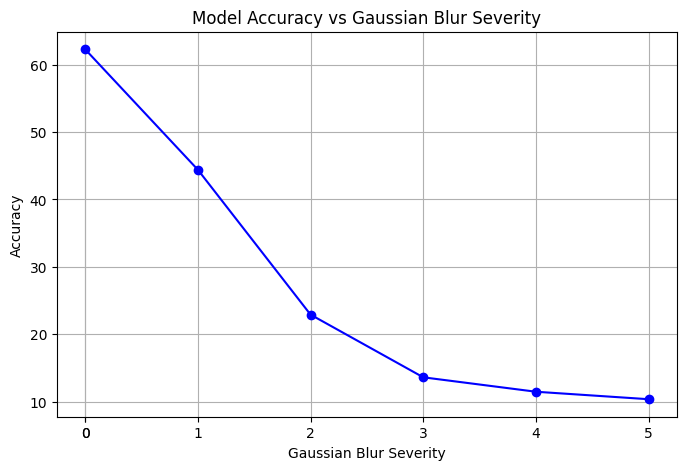

-10.506285714285715

In [116]:
corr_kwargs={"corrname": "gaussian_blur"}
augmentation_gradient(model, test_loader2, imagecorrupt_func, corr_kwargs=corr_kwargs)

Evaluating on severity 0...
Accuracy at severity 0: 62.2900
Evaluating on severity 1...
Accuracy at severity 1: 38.1600
Evaluating on severity 2...
Accuracy at severity 2: 22.7300
Evaluating on severity 3...
Accuracy at severity 3: 15.8300
Evaluating on severity 4...
Accuracy at severity 4: 13.1000
Evaluating on severity 5...
Accuracy at severity 5: 12.1900


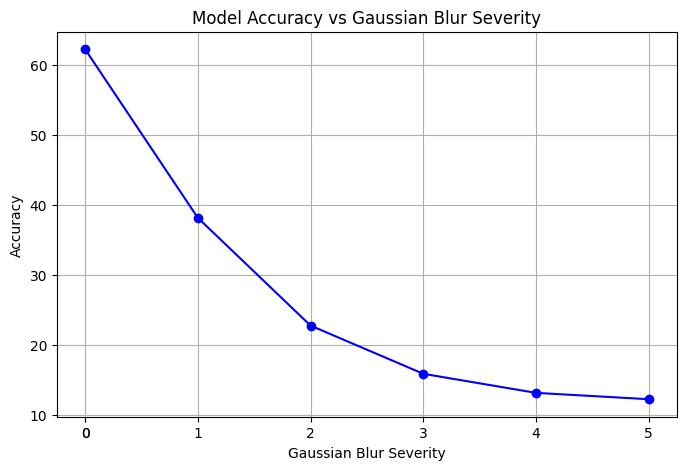

-9.502285714285714

In [117]:
def augly_func(images_np, severity, augly_func, aug_params):
    return np.array([aug_np_wrapper(img, augly_func, **aug_params) for img in images_np])

def augly_wrapper(images_np, severity, corr_kwargs):
    augmentations = [
        (blur, {'radius': lambda s: s}),  # Corrected: Replaced 'severity' with lambda
        (brightness, {'factor': lambda s: 1 + 0.1 * s}),
        (contrast, {'factor': lambda s: s}),  # Corrected
        (random_noise, {'mean': lambda s: 0.0001 * s, 'var': lambda s: 0.00001})
    ]
    
    aug_kwargs = None
    for aug_func, param_dict in augmentations:
        if corr_kwargs['augly_func'] == aug_func:
            aug_kwargs = {k: (v(severity) if callable(v) else v) for k, v in param_dict.items()}
            break
            
    if aug_kwargs is None:
        raise ValueError("Augmentation function not found in list.")
    
    return augly_func(images_np, severity, corr_kwargs['augly_func'], aug_kwargs)

corr_kwargs = {"augly_func": blur}
augmentation_gradient(model, test_loader2, augly_wrapper, corr_kwargs=corr_kwargs)


In [139]:
def augly_combination_gradients(model, test_loader):
    augmentation_methods = [blur, brightness, contrast, random_noise]
    augmentation_dict = {}
    augmentation_methods_str=  ['blur', 'brightness', 'contrast', 'random_noise']
    for m, mstr in zip(augmentation_methods, augmentation_methods_str):
        corr_kwargs = {"augly_func": m}
        gradient, accuracies = augmentation_gradient(model, test_loader, augly_wrapper, corr_kwargs)
        first_drop = accuracies[1] - accuracies[0]
        
        print(accuracies, first_drop)
        print(mstr, 'augmentation method gradient:', gradient)
        augmentation_dict[mstr] = (gradient, first_drop)
        
        print()
    return augmentation_dict

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 17.5600
Evaluating on severity 2...
Accuracy at severity 2: 13.2300
Evaluating on severity 3...
Accuracy at severity 3: 12.4600
Evaluating on severity 4...
Accuracy at severity 4: 11.9800
Evaluating on severity 5...
Accuracy at severity 5: 11.6800


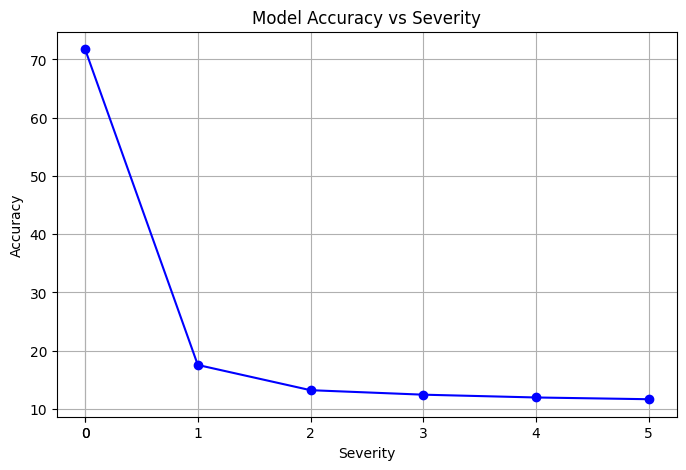

[71.75, 17.56, 13.23, 12.46, 11.98, 11.68] -54.19
<function blur at 0x7f4a0ad50fe0> augmentation method gradient: -9.081714285714284

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 24.3800
Evaluating on severity 2...
Accuracy at severity 2: 24.3300
Evaluating on severity 3...
Accuracy at severity 3: 24.0900
Evaluating on severity 4...
Accuracy at severity 4: 23.7500
Evaluating on severity 5...
Accuracy at severity 5: 23.6700


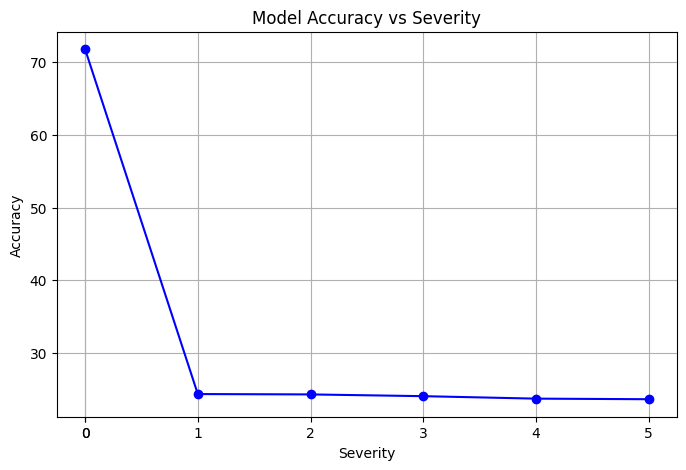

[71.75, 24.38, 24.33, 24.09, 23.75, 23.67] -47.370000000000005
<function brightness at 0x7f4a0ad51120> augmentation method gradient: -6.929428571428573

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 24.3400
Evaluating on severity 2...
Accuracy at severity 2: 29.4300
Evaluating on severity 3...
Accuracy at severity 3: 30.3300
Evaluating on severity 4...
Accuracy at severity 4: 30.2800
Evaluating on severity 5...
Accuracy at severity 5: 29.8700


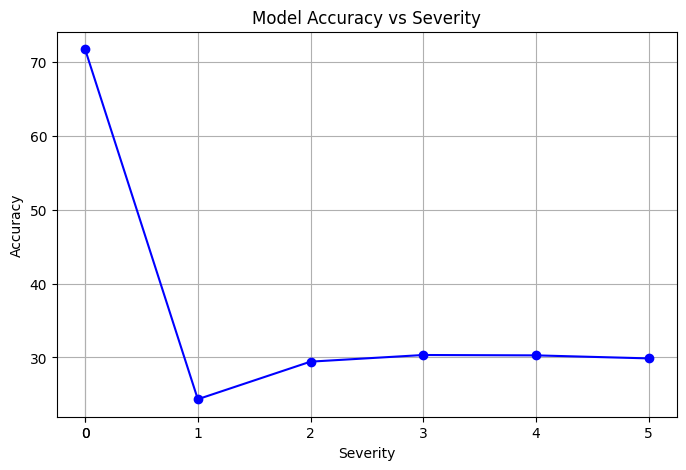

[71.75, 24.34, 29.43, 30.33, 30.28, 29.87] -47.41
<function contrast at 0x7f4a0ad514e0> augmentation method gradient: -5.448

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 24.3200
Evaluating on severity 2...
Accuracy at severity 2: 24.3400
Evaluating on severity 3...
Accuracy at severity 3: 24.3500
Evaluating on severity 4...
Accuracy at severity 4: 24.3200
Evaluating on severity 5...
Accuracy at severity 5: 24.3400


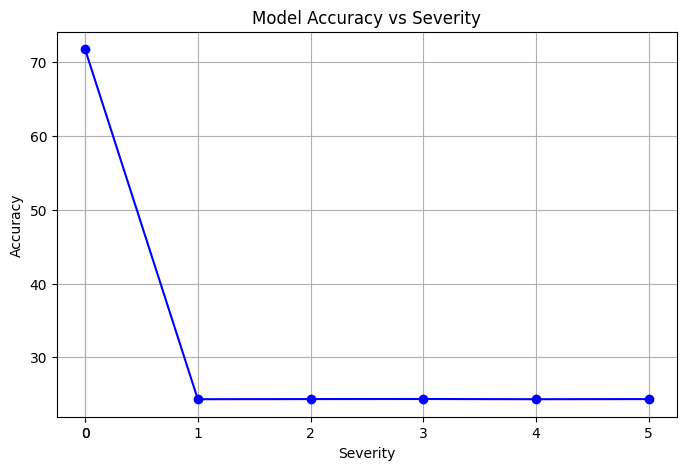

[71.75, 24.32, 24.34, 24.35, 24.32, 24.34] -47.43
<function random_noise at 0x7f4a0ad523e0> augmentation method gradient: -6.772571428571427



{'blur': (-9.081714285714284, -54.19),
 'brightness': (-6.929428571428573, -47.370000000000005),
 'contrast': (-5.448, -47.41),
 'random_noise': (-6.772571428571427, -47.43)}

In [140]:
aug_dict = augly_combination_gradients(model, test_loader2)
aug_dict

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 23.7500
Evaluating on severity 2...
Accuracy at severity 2: 22.9100
Evaluating on severity 3...
Accuracy at severity 3: 21.5400
Evaluating on severity 4...
Accuracy at severity 4: 17.8200
Evaluating on severity 5...
Accuracy at severity 5: 13.3500


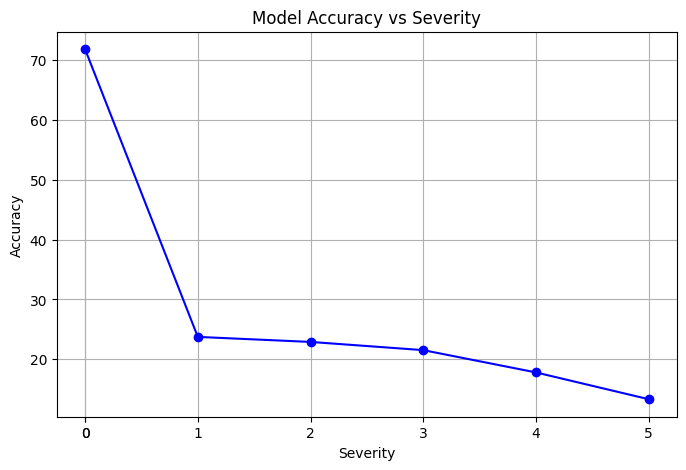

gaussian_noise augmentation method gradient: -8.890285714285715

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 18.8500
Evaluating on severity 2...
Accuracy at severity 2: 17.6000
Evaluating on severity 3...
Accuracy at severity 3: 16.6300
Evaluating on severity 4...
Accuracy at severity 4: 16.1400
Evaluating on severity 5...
Accuracy at severity 5: 14.4300


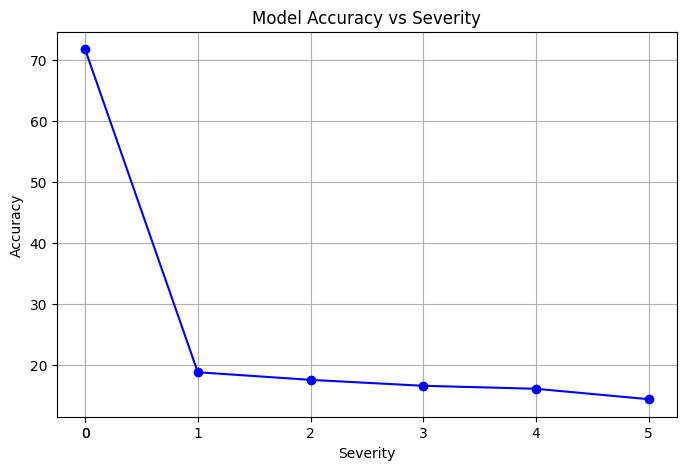

fog augmentation method gradient: -8.44857142857143

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 23.4600
Evaluating on severity 2...
Accuracy at severity 2: 22.6900
Evaluating on severity 3...
Accuracy at severity 3: 21.3700
Evaluating on severity 4...
Accuracy at severity 4: 20.1000
Evaluating on severity 5...
Accuracy at severity 5: 18.9700


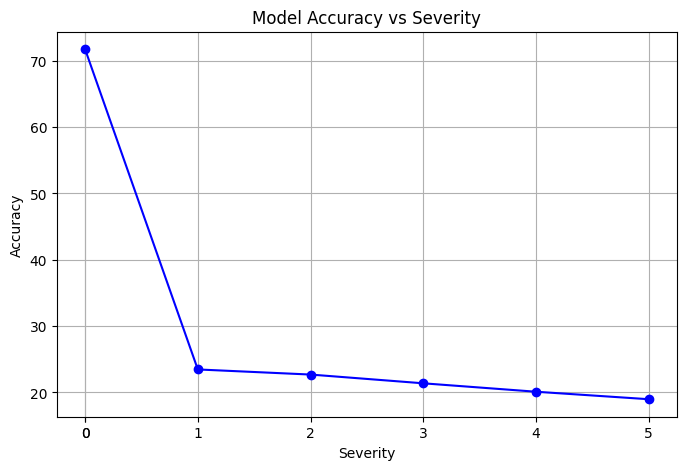

brightness augmentation method gradient: -7.865714285714286

Evaluating on severity 0...
Accuracy at severity 0: 71.7500
Evaluating on severity 1...
Accuracy at severity 1: 19.4900
Evaluating on severity 2...
Accuracy at severity 2: 18.6600
Evaluating on severity 3...
Accuracy at severity 3: 17.7600
Evaluating on severity 4...
Accuracy at severity 4: 17.1600
Evaluating on severity 5...
Accuracy at severity 5: 16.5700


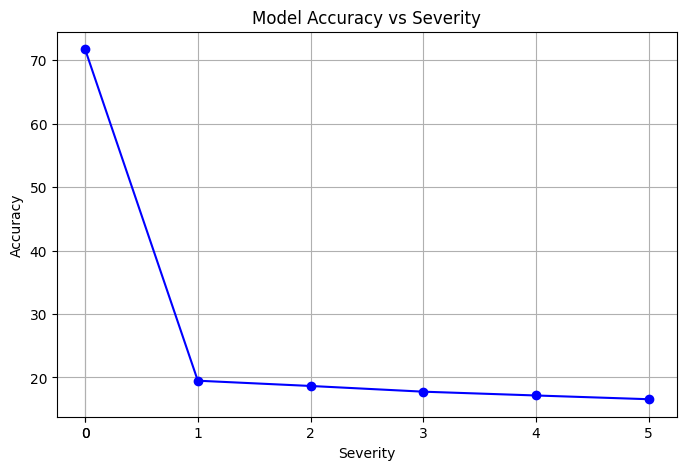

zoom_blur augmentation method gradient: -8.108285714285715



{'gaussian_noise': (-8.890285714285715, -48.0),
 'fog': (-8.44857142857143, -52.9),
 'brightness': (-7.865714285714286, -48.29),
 'zoom_blur': (-8.108285714285715, -52.260000000000005)}

In [142]:
def imagecorr_combination_gradients(model, test_loader):
#     augmentation_methods = [blur, brightness, contrast, random_noise]
    augmentation_dict = {}
    augmentation_methods_str=  ['gaussian_noise', 'fog', 'brightness', 'zoom_blur']
    for mstr in augmentation_methods_str:
        corr_kwargs = {"corrname": mstr}
        gradient, accuracies = augmentation_gradient(model, test_loader, imagecorrupt_func, corr_kwargs)
        first_drop = accuracies[1] - accuracies[0]
        augmentation_dict[mstr] = (gradient, first_drop)
        print(mstr, 'augmentation method gradient:', gradient)
        print()
    return augmentation_dict

aug_dict2 = imagecorr_combination_gradients(model, test_loader2)
aug_dict2

In [ ]:
#retraining

In [143]:
def get_partially_corrupted_dataloader(testloader, corr_func, severity=1, corr_kwargs=None):
    if corr_kwargs is None:
        corr_kwargs = {}  # Default to an empty dictionary
    
    corrupted_images = []
    corrupted_labels = []
    
    for images, labels in testloader:

        if np.random.random() > 0.5:
            corrupted = images
        else:
            images_np = (images * 255).byte().numpy().transpose(0, 2, 3, 1)  # Convert to HWC format and uint8
            
            # Apply corruption function with provided parameters
            corrupted = corr_func(images_np, severity, corr_kwargs)

            corrupted = torch.tensor(corrupted.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0  # Convert back to CHW format and normalize
        corrupted_images.append(corrupted)
        corrupted_labels.append(labels)
        corrupted_images.append(images)
        corrupted_labels.append(labels)
    
    corrupted_dataset = torch.utils.data.TensorDataset(torch.cat(corrupted_images), torch.cat(corrupted_labels))
    return torch.utils.data.DataLoader(corrupted_dataset, batch_size=128, shuffle=False)

In [121]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import random

# train_pc_loader = get_partially_corrupted_dataloader(train_loader, imagecorrupt_func)

train_pc_loader = get_partially_corrupted_dataloader(train_loader, 
                                                    augly_wrapper, 
                                                    severity=1,
                                                    corr_kwargs={"corrname": "snow"})

def train_model(model, optimizer, train_loader, num_epochs=15):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss / len(train_loader):.4f}")
        
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# print("Training model on clean train data...")
train_model(model, optimizer, train_pc_loader , num_epochs=15)

Epoch [1/15] - Loss: 1.9494
Epoch [2/15] - Loss: 1.2635
Epoch [3/15] - Loss: 0.9404
Epoch [4/15] - Loss: 0.7229
Epoch [5/15] - Loss: 0.5569
Epoch [6/15] - Loss: 0.4403
Epoch [7/15] - Loss: 0.3663
Epoch [8/15] - Loss: 0.3302
Epoch [9/15] - Loss: 0.2948
Epoch [10/15] - Loss: 0.2322
Epoch [11/15] - Loss: 0.1817
Epoch [12/15] - Loss: 0.1440
Epoch [13/15] - Loss: 0.1119
Epoch [14/15] - Loss: 0.0847
Epoch [15/15] - Loss: 0.0677


In [148]:
def get_partially_corrupted_imagecorr_dataloader(testloader):
    aug_methods = ['gaussian_noise', 'fog', 'brightness', 'zoom_blur']
    
    corrupted_images = []
    corrupted_labels = []
    
    for images, labels in testloader:

        if np.random.random() > 0.8:
            corrupted = images
        else:
            images_np = (images * 255).byte().numpy().transpose(0, 2, 3, 1)  # Convert to HWC format and uint8
            
            random_index = int(4 * np.random.random())
            aug_method = aug_methods[random_index]
            
            
            # Apply corruption function with provided parameters
            corr_kwargs = {'corrname': aug_method}
            corrupted = imagecorrupt_func(images_np, 1, corr_kwargs)

            corrupted = torch.tensor(corrupted.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0  # Convert back to CHW format and normalize
        corrupted_images.append(corrupted)
        corrupted_labels.append(labels)
        corrupted_images.append(images)
        corrupted_labels.append(labels)
    
    corrupted_dataset = torch.utils.data.TensorDataset(torch.cat(corrupted_images), torch.cat(corrupted_labels))
    return torch.utils.data.DataLoader(corrupted_dataset, batch_size=128, shuffle=False)


train_pci_loader = get_partially_corrupted_imagecorr_dataloader(train_loader)

In [149]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# print("Training model on clean train data...")
train_model(model, optimizer, train_pci_loader, num_epochs=15)

Epoch [1/15] - Loss: 0.8156
Epoch [2/15] - Loss: 0.6571
Epoch [3/15] - Loss: 0.5799
Epoch [4/15] - Loss: 0.5297
Epoch [5/15] - Loss: 0.4927
Epoch [6/15] - Loss: 0.4525
Epoch [7/15] - Loss: 0.4228
Epoch [8/15] - Loss: 0.3851
Epoch [9/15] - Loss: 0.3617
Epoch [10/15] - Loss: 0.3255
Epoch [11/15] - Loss: 0.3114
Epoch [12/15] - Loss: 0.2946
Epoch [13/15] - Loss: 0.2724
Epoch [14/15] - Loss: 0.2480
Epoch [15/15] - Loss: 0.2269


In [152]:
import copy
model_no_weights = copy.deepcopy(model)
model_no_weights.apply(lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None)
acc, _, _ = evaluate(model_no_weights, train_loader); print('no aug:', acc)

no aug: 10.136


In [150]:
acc, _, _ = evaluate(model, train_loader); print('no aug:', acc)
acc, _, _ = evaluate(model, train_pci_loader); print('some aug:', acc)

no aug: 94.506
some aug: 88.557


In [157]:
print("making copies of model")
model_copy = copy.deepcopy(model)
model_no_weights = copy.deepcopy(model)
model_no_weights.apply(
    lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None
)
train_loader_corr = get_partially_corrupted_imagecorr_dataloader(train_loader)

making copies of model


In [158]:
print("training new models")
optimizer = optim.Adam(model_copy.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
train_model(model_copy, optimizer, train_loader_corr, num_epochs=15)
optimizer = optim.Adam(model_no_weights.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
train_model(model_no_weights, optimizer, train_loader_corr, num_epochs=15)


training new models
Epoch [1/15] - Loss: 0.5371
Epoch [2/15] - Loss: 0.4024
Epoch [3/15] - Loss: 0.3323
Epoch [4/15] - Loss: 0.2974
Epoch [5/15] - Loss: 0.2731
Epoch [6/15] - Loss: 0.2467
Epoch [7/15] - Loss: 0.2263
Epoch [8/15] - Loss: 0.2058
Epoch [9/15] - Loss: 0.1885
Epoch [10/15] - Loss: 0.1777
Epoch [11/15] - Loss: 0.1656
Epoch [12/15] - Loss: 0.1571
Epoch [13/15] - Loss: 0.1517
Epoch [14/15] - Loss: 0.1341
Epoch [15/15] - Loss: 0.1293
Epoch [1/15] - Loss: 1.6169
Epoch [2/15] - Loss: 1.2396
Epoch [3/15] - Loss: 1.0731
Epoch [4/15] - Loss: 0.9553
Epoch [5/15] - Loss: 0.8581
Epoch [6/15] - Loss: 0.7748
Epoch [7/15] - Loss: 0.6994
Epoch [8/15] - Loss: 0.6318
Epoch [9/15] - Loss: 0.5788
Epoch [10/15] - Loss: 0.5358
Epoch [11/15] - Loss: 0.4908
Epoch [12/15] - Loss: 0.4585
Epoch [13/15] - Loss: 0.4178
Epoch [14/15] - Loss: 0.3761
Epoch [15/15] - Loss: 0.3462


In [162]:
print("evaluating new models")
test_loader_corr = get_partially_corrupted_imagecorr_dataloader(test_loader2)

test_acc_dict = {}
test_acc_dict['original_model'] = {}
test_acc_dict['copy_model'] = {}
test_acc_dict['scratch_model'] = {}
acc, _, _ = evaluate(model, test_loader2); test_acc_dict['original_model']['non_corrupted'] = acc
acc, _, _ = evaluate(model, test_loader_corr); test_acc_dict['original_model']['corrupted'] = acc
acc, _, _ = evaluate(model_copy, test_loader2); test_acc_dict['copy_model']['non_corrupted'] = acc
acc, _, _ = evaluate(model_copy, test_loader_corr); test_acc_dict['copy_model']['corrupted'] = acc    
acc, _, _ = evaluate(model_no_weights, test_loader2); test_acc_dict['scratch_model']['non_corrupted'] = acc
acc, _, _ = evaluate(model_no_weights, test_loader_corr); test_acc_dict['scratch_model']['corrupted'] = acc

evaluating new models


In [163]:
test_acc_dict

{'original_model': {'non_corrupted': 67.55, 'corrupted': 59.085},
 'copy_model': {'non_corrupted': 68.0, 'corrupted': 59.585},
 'scratch_model': {'non_corrupted': 67.46, 'corrupted': 60.21}}

In [154]:
import copy

def retrain_experiment(model, train_loader, test_loader, get_corrupted_dataloader_func):
    # Assume you have an unknown model
    print("making copies of model")
    model_copy = copy.deepcopy(model)
    model_no_weights = copy.deepcopy(model)
    model_no_weights.apply(
        lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None
    )
    train_loader_corr = get_corrupted_dataloader_func(train_loader)
    
    print("training new models")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    train_model(model_copy, optimizer, train_loader_corr, num_epochs=15)
    train_model(model_no_weights, optimizer, train_loader_corr, num_epochs=15)
    
    print("evaluating new models")
    test_loader_corr = get_corrupted_dataloader_func(test_loader)
    
    test_acc_dict = {}
    test_acc_dict['original_model'] = {}
    test_acc_dict['copy_model'] = {}
    test_acc_dict['scratch_model'] = {}
    acc, _, _ = evaluate(model, test_loader); test_acc_dict['original_model']['non_corrupted'] = acc
    acc, _, _ = evaluate(model, test_loader_corr); test_acc_dict['original_model']['corrupted'] = acc
    acc, _, _ = evaluate(model_copy, test_loader); test_acc_dict['copy_model']['non_corrupted'] = acc
    acc, _, _ = evaluate(model_copy, test_loader_corr); test_acc_dict['copy_model']['corrupted'] = acc    
    acc, _, _ = evaluate(model_no_weights, test_loader); test_acc_dict['scratch_model']['non_corrupted'] = acc
    acc, _, _ = evaluate(model_no_weights, test_loader_corr); test_acc_dict['scratch_model']['corrupted'] = acc
    
    return model_copy, model_no_weights, test_acc_dict



In [155]:
model_copy, model_no_weights, test_acc_dict = retrain_experiment(model, 
                                                                 train_loader, 
                                                                 test_loader2, 
                                                                 get_partially_corrupted_imagecorr_dataloader)

making copies of model
training new models
Epoch [1/15] - Loss: 0.6880
Epoch [2/15] - Loss: 0.6880
Epoch [3/15] - Loss: 0.6880
Epoch [4/15] - Loss: 0.6880
Epoch [5/15] - Loss: 0.6880


KeyboardInterrupt: 

In [ ]:
#ignore for now

In [123]:
acc, _, _ = evaluate(model, train_pc_loader); print(acc)

97.23907766990291


In [124]:
acc, _, _ = evaluate(model, train_c_loader); print(acc)

33.624


In [79]:
train_c_loader=  get_corrupted_dataloader(train_loader, imagecorrupt_func)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
train_model(model, optimizer, train_c_loader , num_epochs=15)

Epoch [1/15] - Loss: 1.3121
Epoch [2/15] - Loss: 1.1351
Epoch [3/15] - Loss: 1.0129
Epoch [4/15] - Loss: 0.9052
Epoch [5/15] - Loss: 0.8188
Epoch [6/15] - Loss: 0.7643
Epoch [7/15] - Loss: 0.7121
Epoch [8/15] - Loss: 0.6475
Epoch [9/15] - Loss: 0.5947
Epoch [10/15] - Loss: 0.5486
Epoch [11/15] - Loss: 0.5043
Epoch [12/15] - Loss: 0.4671
Epoch [13/15] - Loss: 0.4170
Epoch [14/15] - Loss: 0.3698
Epoch [15/15] - Loss: 0.3400


In [ ]:
#displaying images

In [167]:
import requests
from PIL import Image
import numpy as np
from io import BytesIO

# URL of the image
image_url = "https://www.naval-group.com/sites/default/files/styles/section_banner_left_right/public/2020-08/D%C3%A9tecter%20avant%20d%E2%80%99%C3%AAtre%20d%C3%A9tect%C3%A9.jpg?itok=M9mSIxmC"

# Fetch the image
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

# Convert to NumPy array
image_array = np.array(image)

# Print shape of the array
print(image_array.shape)  # (height, width, channels)

(614, 1000, 3)


In [182]:
from nrtk.impls.perturb_image.generic.cv2.blur import AverageBlurPerturber, GaussianBlurPerturber, MedianBlurPerturber
from nrtk.impls.perturb_image.generic.PIL.enhance import (
    BrightnessPerturber,
    ColorPerturber,
    ContrastPerturber,
    SharpnessPerturber,
)
from nrtk.impls.perturb_image.generic.skimage.random_noise import (
    GaussianNoisePerturber,
    PepperNoisePerturber,
    SaltAndPepperNoisePerturber,
    SaltNoisePerturber,
    SpeckleNoisePerturber,
)

def corrupt_and_plot_nrtk_all(img, seed=42):
    #img np array
    severities = [0, 1, 2]
    
    perturbations = [
        (SaltNoisePerturber, {'rng': seed, 'amount': lambda s: 0.25 * s}),
        (PepperNoisePerturber, {'rng': np.random.default_rng(seed), 'amount': lambda s: 0.25 * s}),
        (SaltAndPepperNoisePerturber, {'rng': np.random.default_rng(seed), 'amount': lambda s: 0.25 * s}),
        (GaussianNoisePerturber, {'rng': seed, 'mean': lambda s: 0.15 * s, 'var': lambda s: 0.01 * s}),
        (SpeckleNoisePerturber, {'rng': seed, 'mean': lambda s: 0.35 * s, 'var': lambda s: 0.01 * s}),
        (AverageBlurPerturber, {'ksize': lambda s: 11 + 2 * s}),
        (GaussianBlurPerturber, {'ksize': lambda s: 11 + 4 * s}),
        (MedianBlurPerturber, {'ksize': lambda s: 11 + 2 * s}),
        (BrightnessPerturber, {'factor': lambda s: 1 + 0.25 * s}),
        (ColorPerturber, {'factor': lambda s: 1 - 0.45 * s}),
        (ContrastPerturber, {'factor': lambda s: 1 + 0.5 * s}),
        (SharpnessPerturber, {'factor': lambda s: 1 - 0.4 * s}),
    ]
    perturb_names = ["Salt Noise", "Pepper Noise", "Salt Pepper Noise", "Gaussian Noise", "Speckle Noise",
                     "Average Blur", "Gaussian Blur", "Median Blur",
                     "Brightness", "Color", "Contrast", "Sharpness"]
    
    fig, axes = plt.subplots(len(perturbations), len(severities), figsize=(30, 30))
    
    for i, (PerturberClass, param_dict) in enumerate(perturbations):
        for j, severity in enumerate(severities):
            if severity == 0:
                corrupted_img = img
            else:
                perturber_params = {k: (v(severity) if callable(v) else v) for k, v in param_dict.items()}
                perturber = PerturberClass(**perturber_params)
                corrupted_img, _ = perturber(img)
            axes[i, j].imshow(corrupted_img)
            #axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(perturb_names[i], fontsize=12, rotation=0, labelpad=40, verticalalignment='center')
    
    for j, severity in enumerate(severities):
        axes[0, j].set_title(f'Severity {severity}', fontsize=12)
    
    plt.tight_layout()
    plt.show()


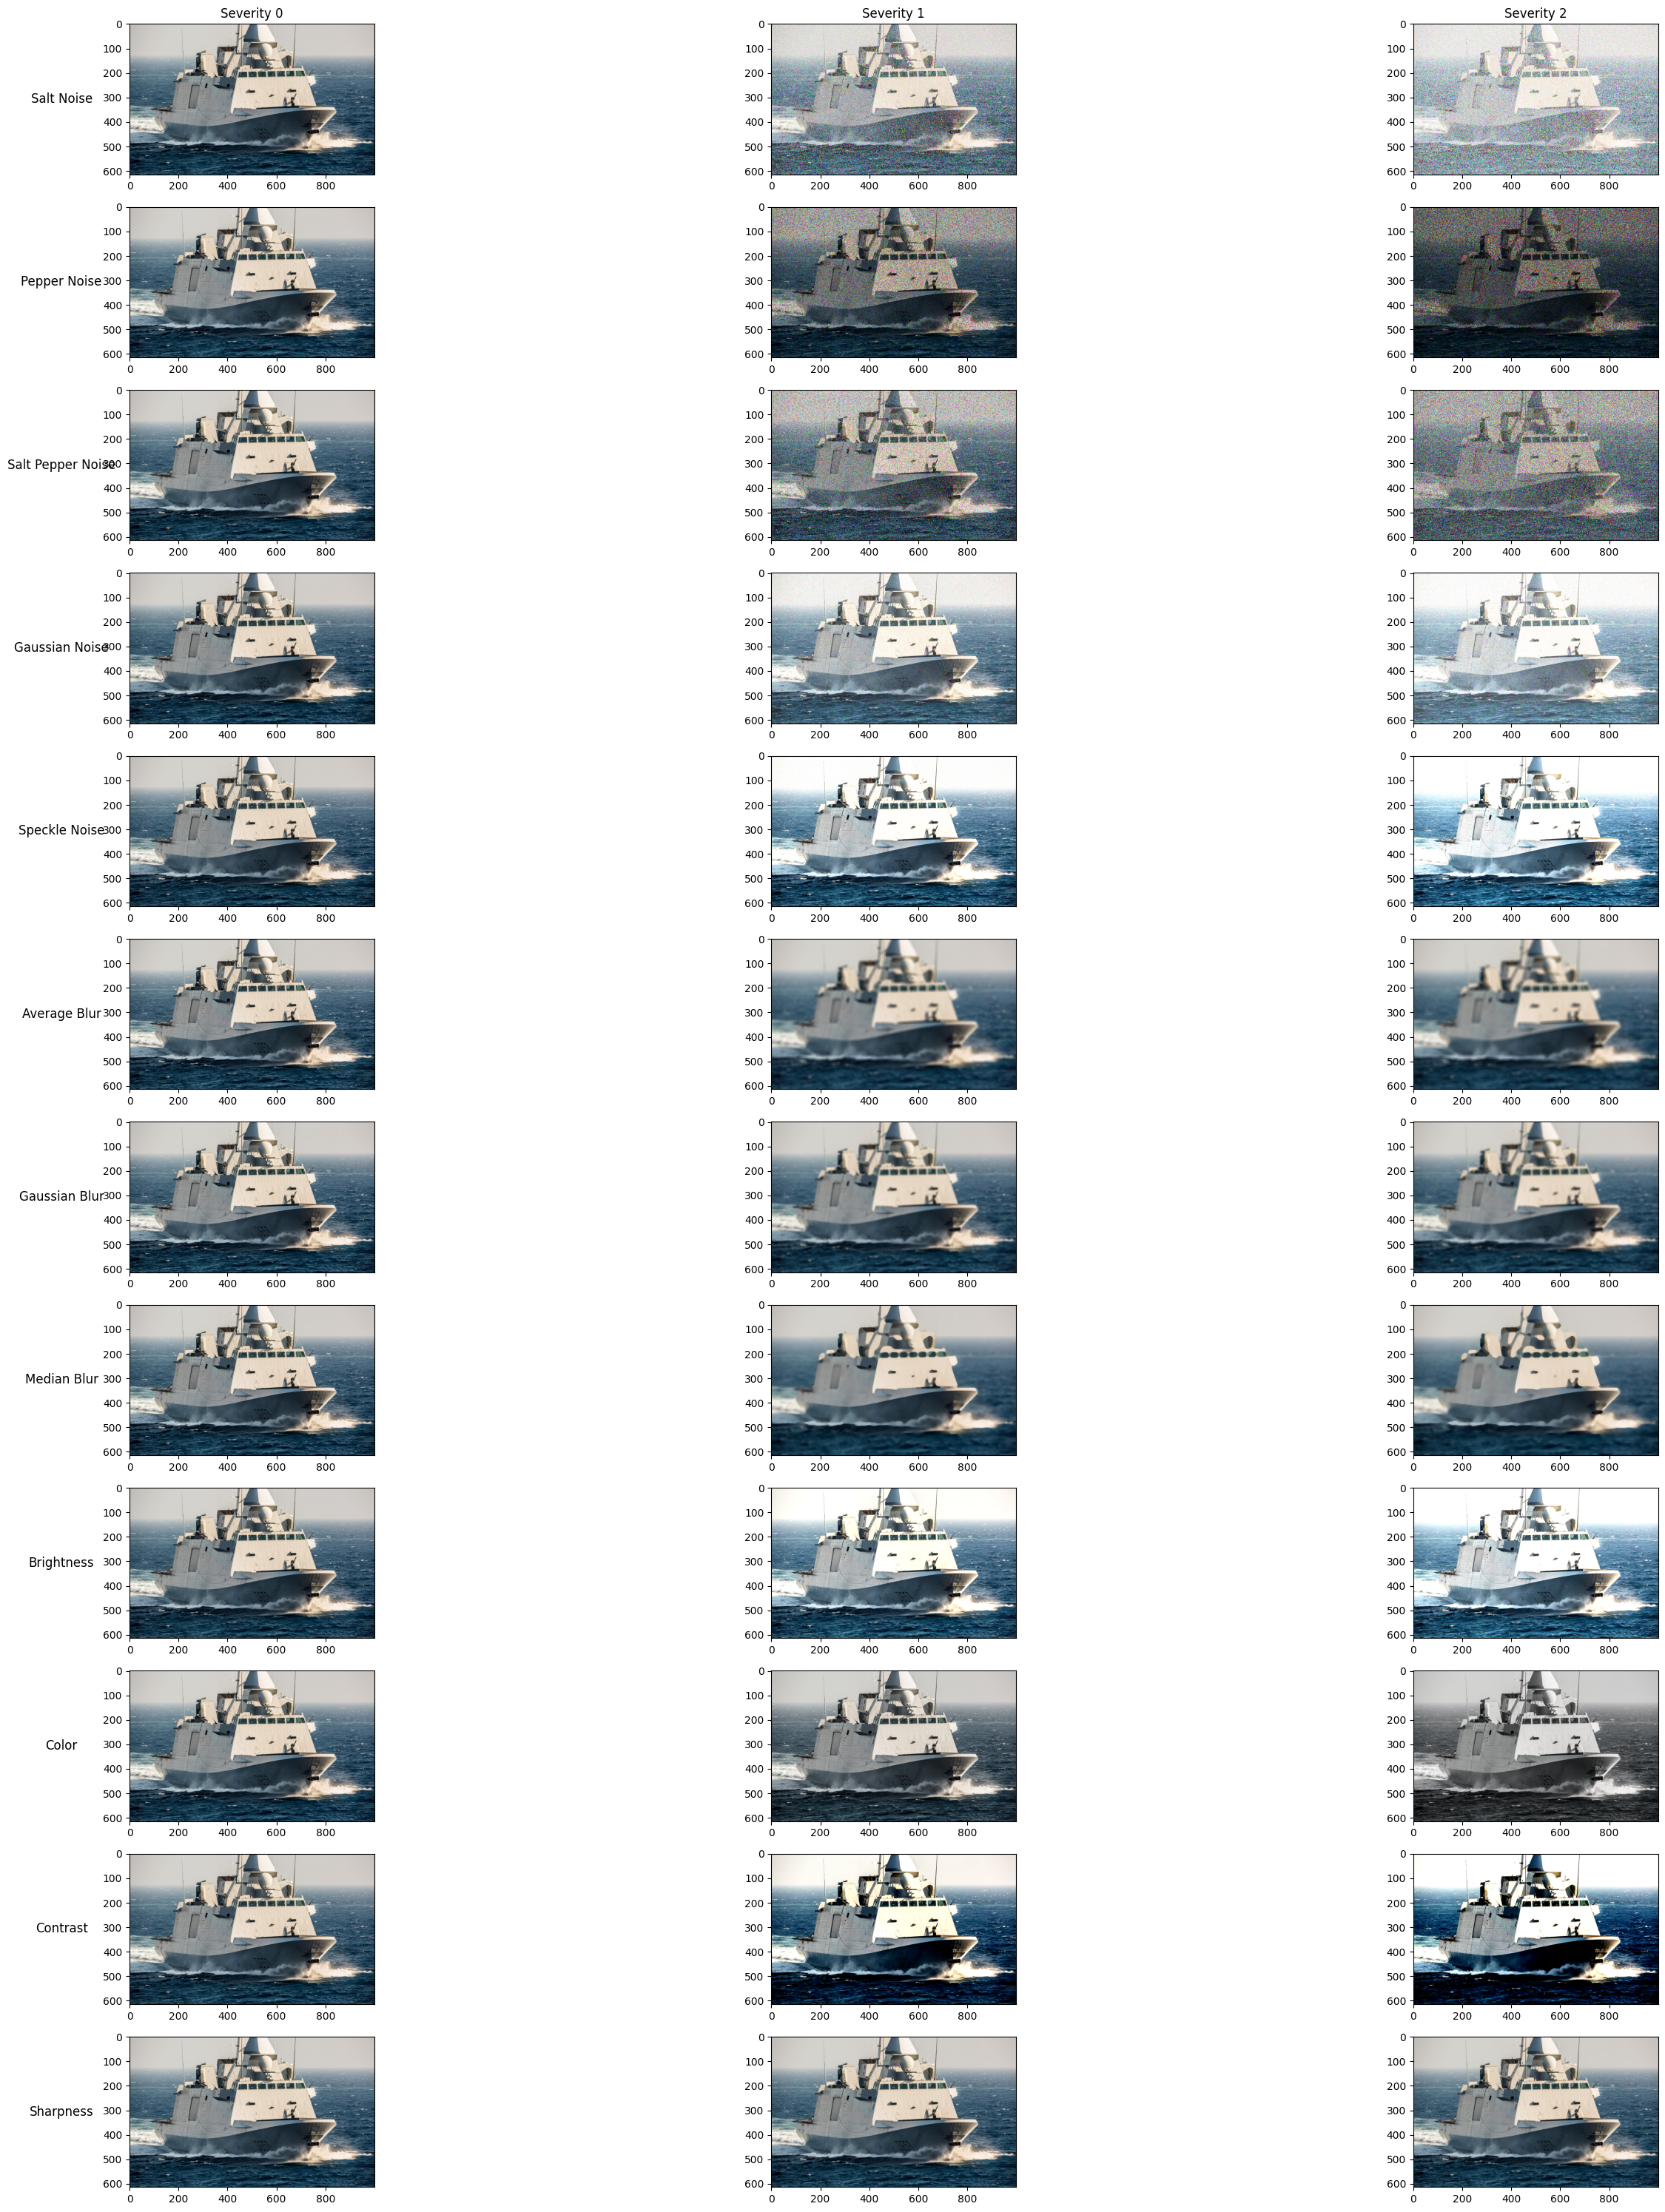

In [183]:
corrupt_and_plot_nrtk_all(image_array)

In [194]:
from augly.image import blur, brightness, random_noise, contrast, color_jitter,pixelization, sharpen
from augly.image import aug_np_wrapper

def corrupt_and_plot_augly(img):
    augmentations = [
        (blur, {'radius': lambda s: 1+s}),
        (brightness, {'factor': lambda s: 1+0.2 * s}),
        (contrast, {'factor': 'severity'}),
        #(random_noise, {'mean': lambda s: 0.000001 * s, 'var': 0.0000001}),
        (sharpen, {'factor': lambda s: 1-0.25*s }),
        (color_jitter, {'brightness_factor': lambda s: 1+0.25*s, 
                        'contrast_factor': lambda s: 1+0.25*s, 
                        'saturation_factor': lambda s: 1+0.25*s}),
        (pixelization, {'ratio': lambda s: 1-0.45*s})
    ]
    aug_names = ["Blur", "Brightness", "Contrast", "Sharpen/", "Color Jitter", "Pixelization"]
    severities = [0, 1, 2]
    
    fig, axes = plt.subplots(len(augmentations), len(severities), figsize=(15, 10))
    
    for i, (aug_func, param_dict) in enumerate(augmentations):
        for j, severity in enumerate(severities):
            if severity != 0:
                aug_params = {k: (v(severity) if callable(v) else severity) for k, v in param_dict.items()}
                corrupted_img = aug_np_wrapper(img, aug_func, **aug_params)
            else:
                corrupted_img = img
            axes[i, j].imshow(corrupted_img)
            #axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(aug_names[i], fontsize=12, rotation=0, labelpad=40, verticalalignment='center')
    
    for j, severity in enumerate(severities):
        axes[0, j].set_title(f'Severity {severity}', fontsize=12)
    
    plt.tight_layout()
    plt.show()

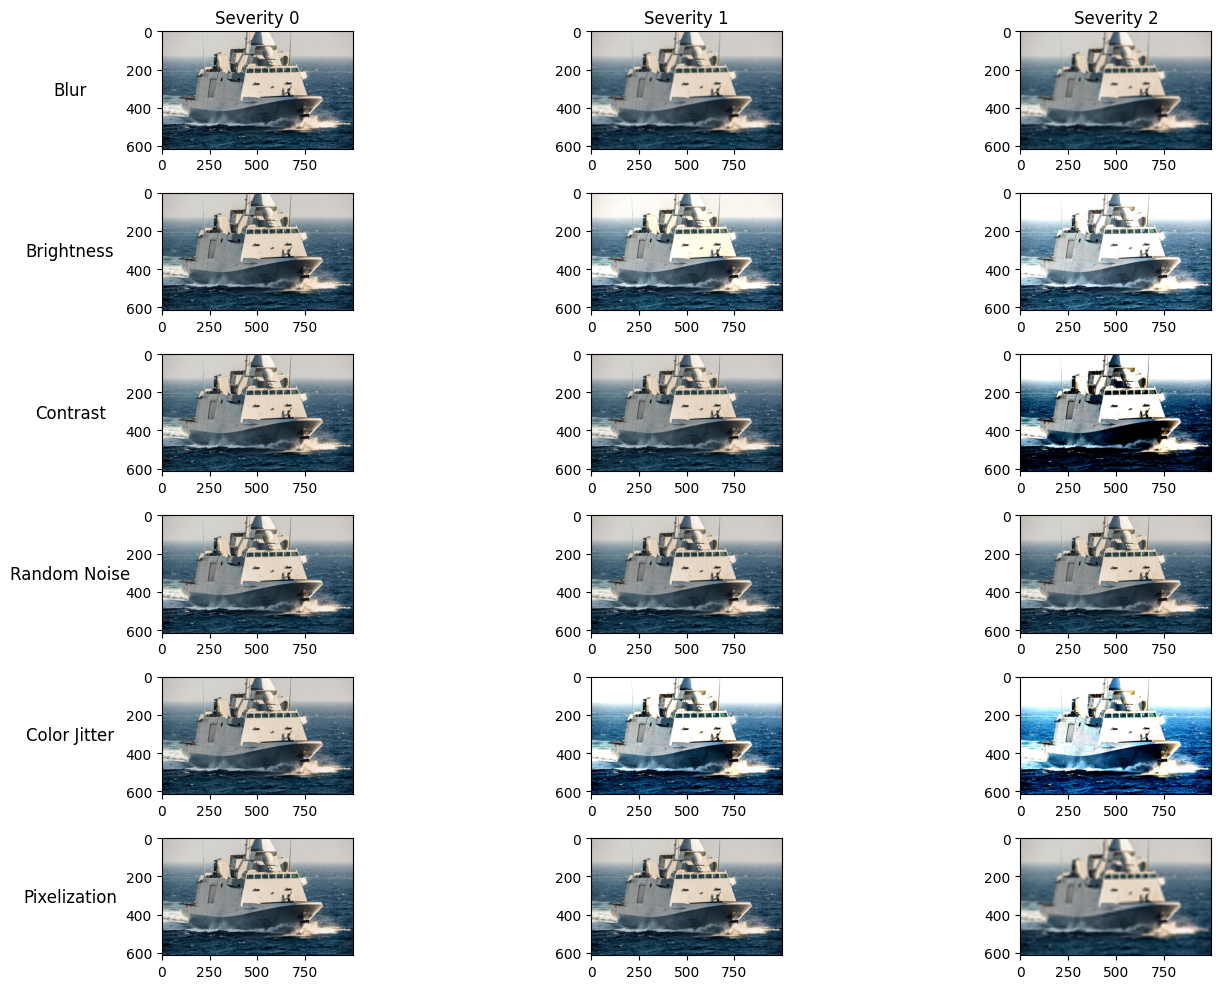

In [195]:
corrupt_and_plot_augly(image_array)

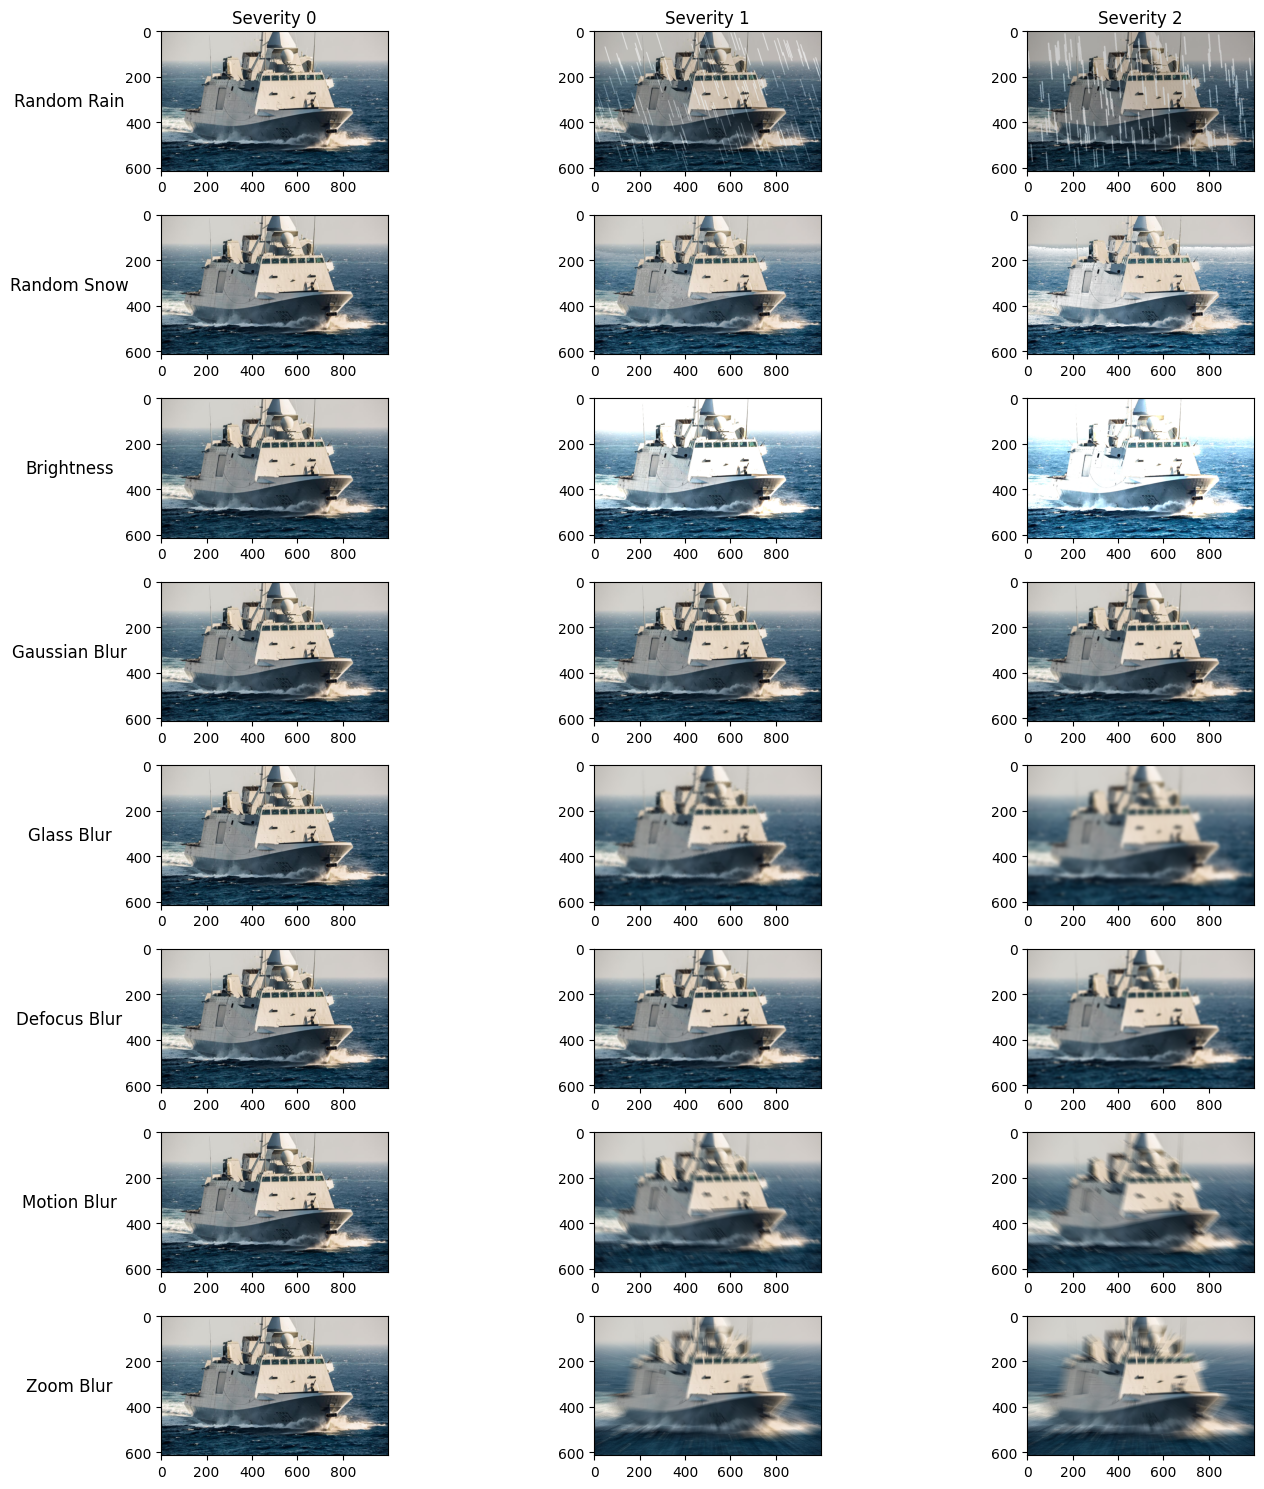

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import albumentations as A
from albumentations.pytorch import ToTensorV2

def corrupt_and_plot_album(img):

    augmentations = [
        (A.RandomRain, {'slant_range': (0, 30), 
                        'drop_length': lambda s: 2*s, 
                        'drop_width': lambda s: s, 
                        'drop_color': (200, 200, 200), 
                        'blur_value': lambda s: 3 + s, 
                        'brightness_coefficient': lambda s: 1 - 0.1*s, 
                        'rain_type': 'drizzle', 
                        'p': 1.0}),
        (A.RandomSnow, {'snow_point_range': lambda s: (0.3+0.1 * s, 0.5 + 0.1* s), 
                        'brightness_coeff': lambda s: 1.0+.25*s, 
                        'p': 1.0}),
        (A.ColorJitter, {'brightness': lambda s: (0.85+0.55*s, 1+0.55*s),
                         'contrast': (1,1),
                         'saturation': (1,1),
                         'hue': (0,0),
                         'p':1}),
        (A.GaussianBlur, {'blur_limit': lambda s: (9 + 6*s, 13 + 6*s), 
                          'sigma_limit':lambda s: (0.25 + 0.25*s, 1.0 + 0.25*s),
                          'p': 1.0}),
        (A.GlassBlur, {'sigma': lambda s: s*2, 'p': 1.0}),
        (A.Defocus, {'radius': lambda s: (3*s,3*s+1), 'alias_blur': lambda s: 2*s, 'p': 1.0}),
        (A.MotionBlur, {'blur_limit': lambda s: (5+8*s, 7+12*s), 'p': 1.0}),
        (A.ZoomBlur, {'max_factor': lambda s: 1 + 0.25 * s, 'p': 1.0})
    ]
    aug_names = ["Random Rain", "Random Snow", "Brightness", "Gaussian Blur", "Glass Blur", "Defocus Blur", "Motion Blur", "Zoom Blur"]
    severities = [0, 1, 2]
    
    fig, axes = plt.subplots(len(augmentations), len(severities), figsize=(15, 15))
    
    for i, (aug_class, param_dict) in enumerate(augmentations):
        for j, severity in enumerate(severities):
            if severity != 0:
                aug_params = {k: (v(severity) if callable(v) else v) for k, v in param_dict.items()}
                transform = A.Compose([aug_class(**aug_params), ToTensorV2()])
                corrupted_img = transform(image=img)['image'].permute(1, 2, 0).numpy()
            else:
                corrupted_img  = img
            axes[i, j].imshow(corrupted_img)
            #axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(aug_names[i], fontsize=12, rotation=0, labelpad=40, verticalalignment='center')
    
    for j, severity in enumerate(severities):
        axes[0, j].set_title(f'Severity {severity}', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Example usage
# corrupt_and_plot('path_to_image.jpg')
# Example usage
corrupt_and_plot_album(image_array)

In [ ]:
#ignore

In [ ]:

# Corrupt test dataset
# def get_corrupted_dataloader(testloader, corr_func, severity=1):
#     corrupted_images = []
#     corrupted_labels = []
    
#     for images, labels in testloader:
        
#         images_np = (images * 255).byte().numpy().transpose(0, 2, 3, 1)  # Convert to HWC format and uint8
#         corrupted = corr_func(images_np, severity)
#         #corrupted = np.array([corrupt(img.astype(np.uint8), corruption_name='gaussian_blur', severity=severity) for img in images_np])
#         #corrupted = np.array([aug_np_wrapper(img, random_noise, **{'mean': 0.1*severity, 'var': 0.001}) for img in images_np])
#         corrupted = torch.tensor(corrupted.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0  # Convert back to CHW format and normalize
#         corrupted_images.append(corrupted)
#         corrupted_labels.append(labels)
    
#     corrupted_dataset = torch.utils.data.TensorDataset(torch.cat(corrupted_images), torch.cat(corrupted_labels))
#     return torch.utils.data.DataLoader(corrupted_dataset, batch_size=128, shuffle=False)



# def extract_logits(test_loader, model, device):
#     """
#     Extracts logits (pre-softmax activations) from the model for all test samples.

#     Args:
#         test_loader: DataLoader containing the noisy test set.
#         model: Trained model.
#         device: CUDA/CPU device.

#     Returns:
#         logits_all: Extracted logits for all test samples.
#         labels_all: True labels for the test samples.
#         indices_all: Indices of test samples.
#     """
#     model.eval()
#     logits_all, labels_all, indices_all = [], [], []

#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Extracting Logits"):
#             images = images.to(device)
#             outputs = model(images)  # Logits (pre-softmax activations)

#             logits_all.append(outputs.cpu().numpy())
#             labels_all.append(labels.numpy())
            

#     logits_all = np.vstack(logits_all)
#     labels_all = np.concatenate(labels_all)
#     indices_all = list(range(len(logits_all)))
#     indices_all = np.array(indices_all)
# #     indices_all = np.concatenate(indices_all)

#     return logits_all, labels_all, indices_all


# def extract_features2(model, dataloader, device):
#     """Extracts features from SimpleCNN's second-last layer."""
#     model.eval()
#     features = []
#     labels = []
    
#     with torch.no_grad():
#         for inputs, targets in tqdm(dataloader):
#             inputs = inputs.to(device)
#             outputs = model(inputs)
#             features.append(outputs.cpu().numpy())
#             labels.append(targets.numpy())

#     features = np.concatenate(features, axis=0)
#     labels = np.concatenate(labels, axis=0)
#     return features, labels

# Extract features from SimpleCNN
# features, labels = extract_features2(model, test_loader, device)


def augly_func(images_np, severity, augly_func, aug_params):
    return np.array([aug_np_wrapper(img, 
                                    augly_func, 
                                    **aug_params) for img in images_np])

def augly_wrapper(images_np, severity, corr_kwargs):
#     aug_kwargs = {"mean": 0.25 * severity, "var": 0.01}
    augmentations = [
        (blur, {'radius': 'severity'}),
        (brightness, {'factor': lambda s: 1+0.1 * s}),
        (contrast, {'factor': 'severity'}),
        (random_noise, {'mean': lambda s: 0.0001 * s, 'var': 0.00001})
    ]
    aug_kwargs = None
    for i, (aug_func, param_dict) in enumerate(augmentations):
        if corr_kwargs['augly_func'] == aug_func:
            aug_kwargs = {k: (v(severity) if callable(v) else severity) for k, v in param_dict.items()}
            break
    if aug_kwargs is None:
        raise Exception("can't find the function")
    return augly_func(images_np, severity, corr_kwargs['augly_func'], aug_kwargs)


corr_kwargs={"augly_func": blur}
augmentation_gradient(model, test_loader2, augly_wrapper, corr_kwargs)